In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

base_path = r"C:\Users\shrut\OneDrive\Desktop\Mutual fund analytics"

nav = pd.read_csv(f"{base_path}/data/processed/nav_history_clean.csv")
aum = pd.read_csv(f"{base_path}/data/processed/aum_by_fund_house_clean.csv")
sip = pd.read_csv(f"{base_path}/data/processed/monthly_sip_inflows_clean.csv")
category = pd.read_csv(f"{base_path}/data/processed/category_inflows_clean.csv")
investor = pd.read_csv(f"{base_path}/data/processed/investor_transactions_clean.csv")
folio = pd.read_csv(f"{base_path}/data/processed/industry_folio_count_clean.csv")
portfolio = pd.read_csv(f"{base_path}/data/processed/portfolio_holdings_clean.csv")
performance = pd.read_csv(f"{base_path}/data/processed/scheme_performance_clean.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [4]:
print("NAV")
print(nav.columns)

print("\nAUM")
print(aum.columns)

print("\nSIP")
print(sip.columns)

print("\nCategory")
print(category.columns)

print("\nInvestor")
print(investor.columns)

print("\nFolio")
print(folio.columns)

print("\nPortfolio")
print(portfolio.columns)

print("\nPerformance")
print(performance.columns)


NAV
Index(['amfi_code', 'date', 'nav'], dtype='str')

AUM
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

SIP
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

Category
Index(['month', 'category', 'net_inflow_crore'], dtype='str')

Investor
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

Folio
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

Portfolio
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

Performance
Index(['amfi_code', 'scheme_name', '

In [5]:
#NAV Trend Analysis
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    fillcolor="green",
    opacity=0.1
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    annotation_text="2024 Correction",
    fillcolor="red",
    opacity=0.1
)

fig.show()

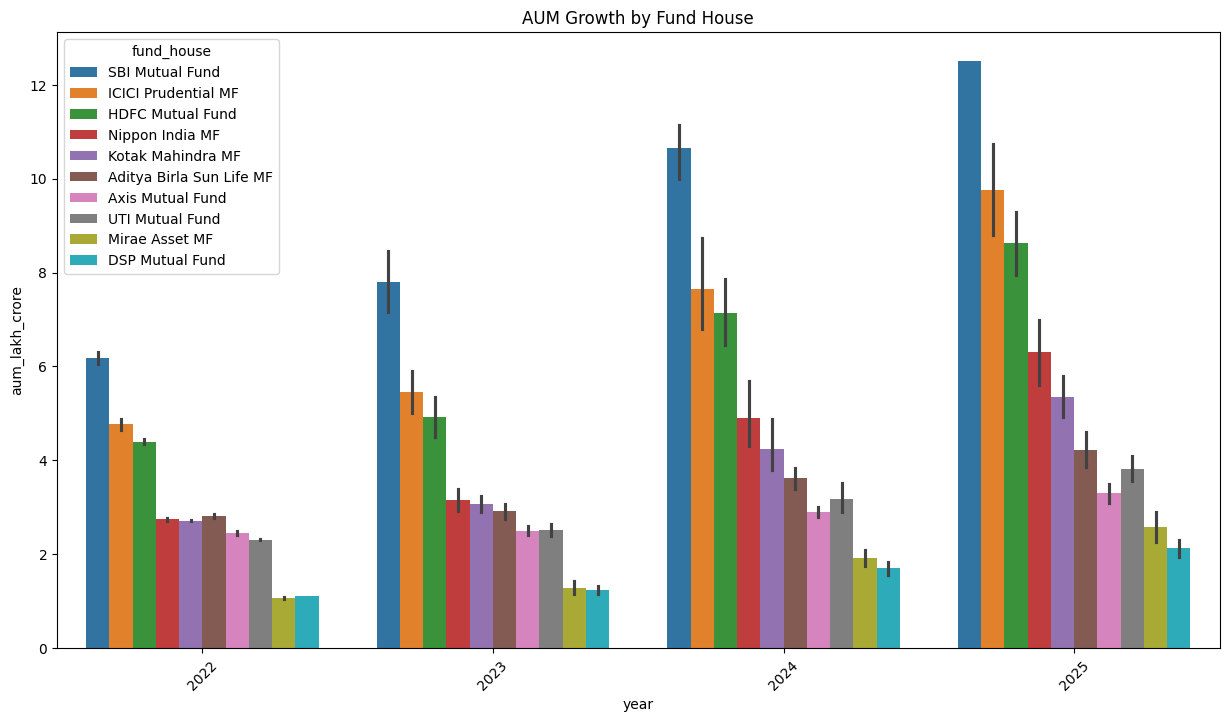

In [6]:
#AUM Growth by Fund House
aum["year"] = pd.to_datetime(aum["date"]).dt.year

plt.figure(figsize=(15,8))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)
plt.show()

In [7]:
#SIP Inflow Trend
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Peak: {max_row['sip_inflow_crore']} Cr"
)

fig.show()

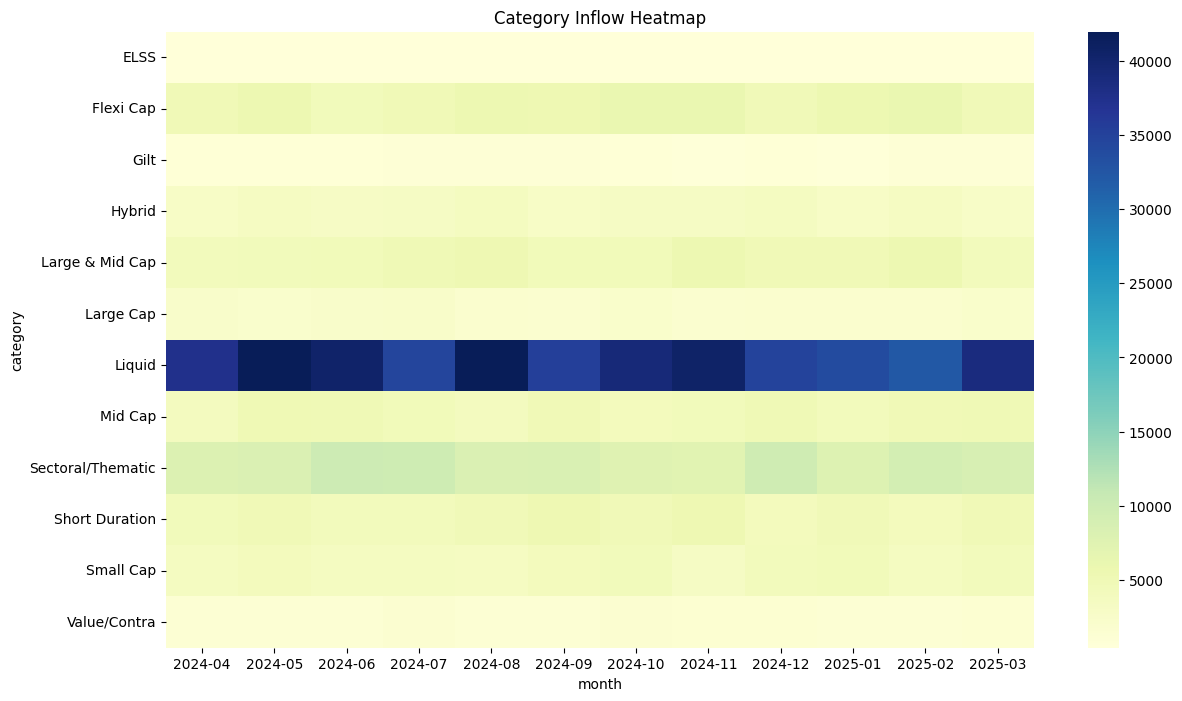

In [8]:
#Category Inflow Heatmap
heatmap_df = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))
sns.heatmap(heatmap_df, cmap="YlGnBu")
plt.title("Category Inflow Heatmap")
plt.show()

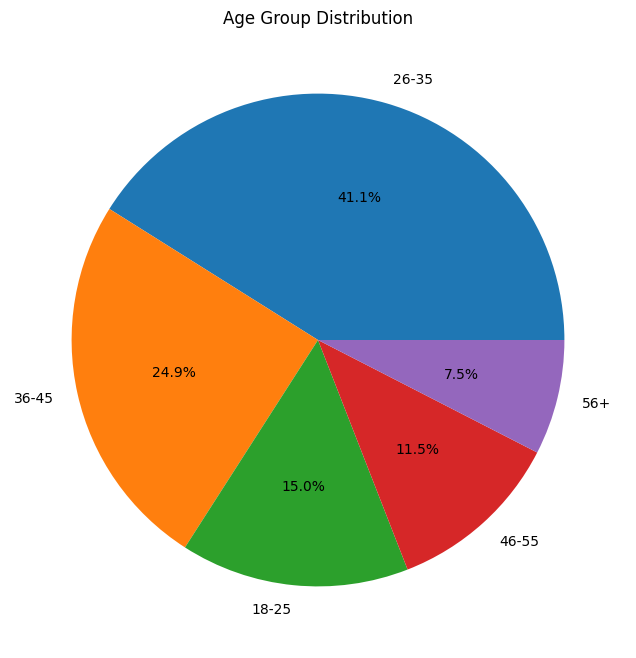

In [9]:
#Age Group Distribution
investor["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Age Group Distribution")
plt.ylabel("")
plt.show()

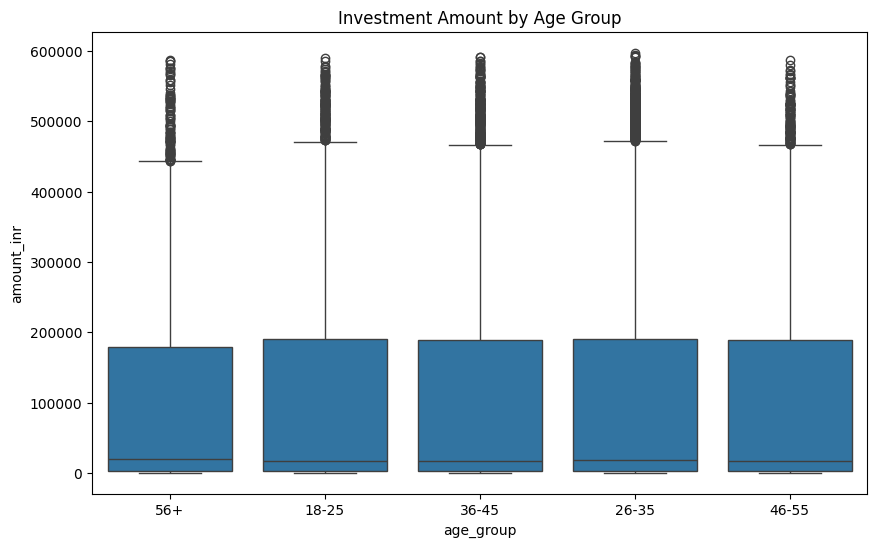

In [10]:
#SIP Amount by Age Group
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.show()

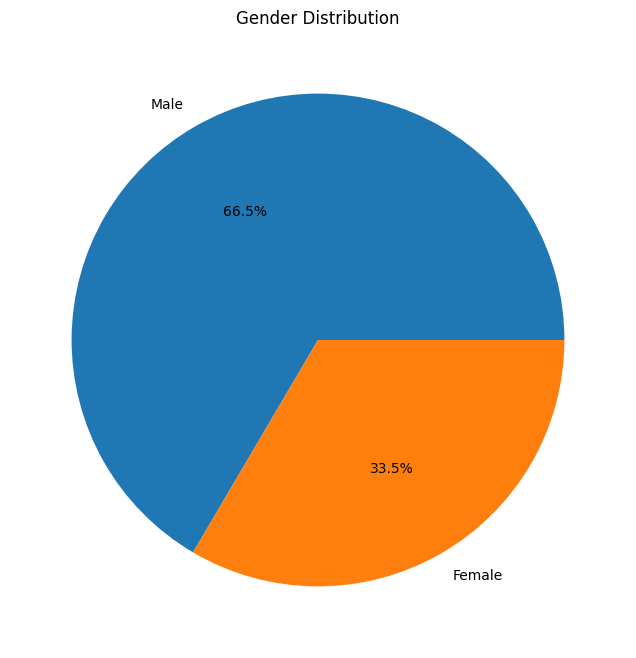

In [11]:
#Gender Split
investor["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

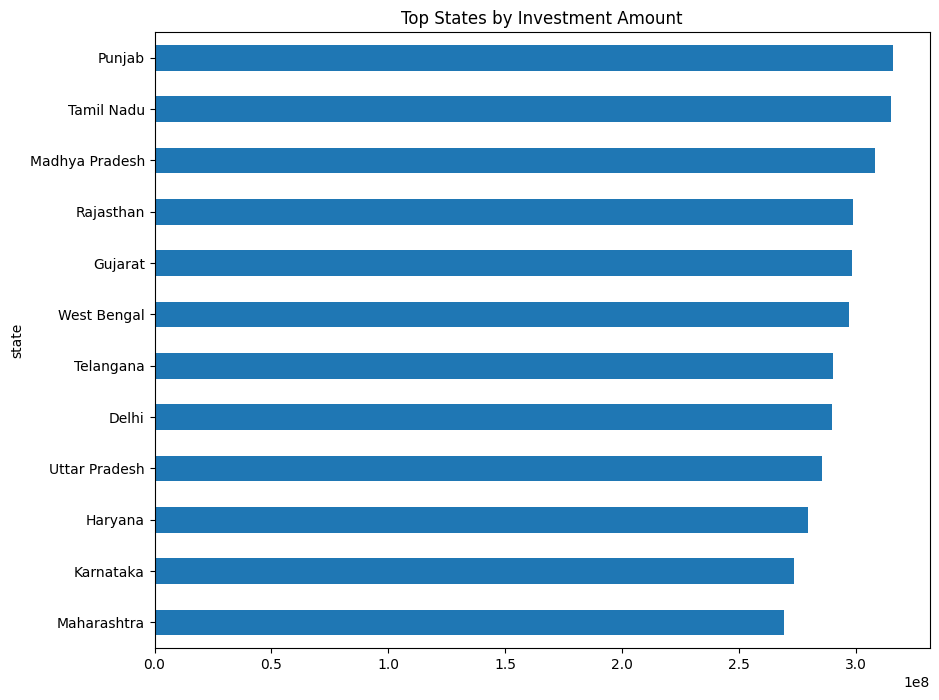

In [12]:
#State-wise Investment
state_data = investor.groupby("state")["amount_inr"].sum()

state_data.sort_values().tail(15).plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Top States by Investment Amount")
plt.show()

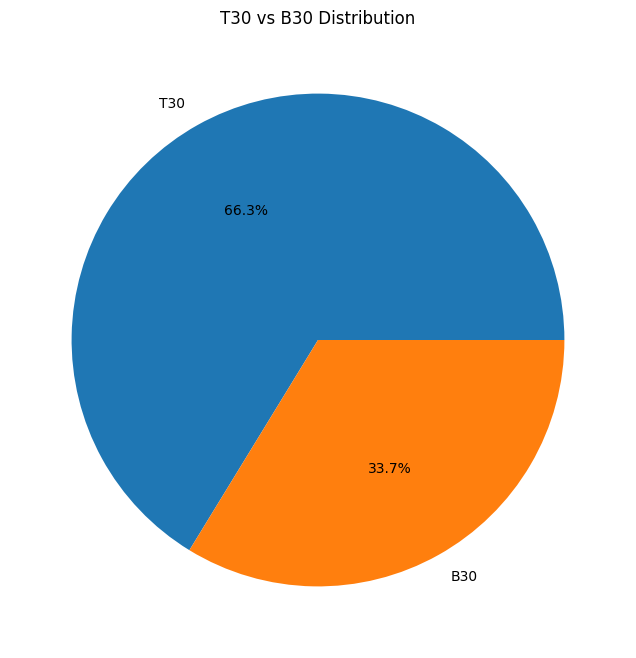

In [13]:
#T30 vs B30 Distribution
investor["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("T30 vs B30 Distribution")
plt.ylabel("")
plt.show()

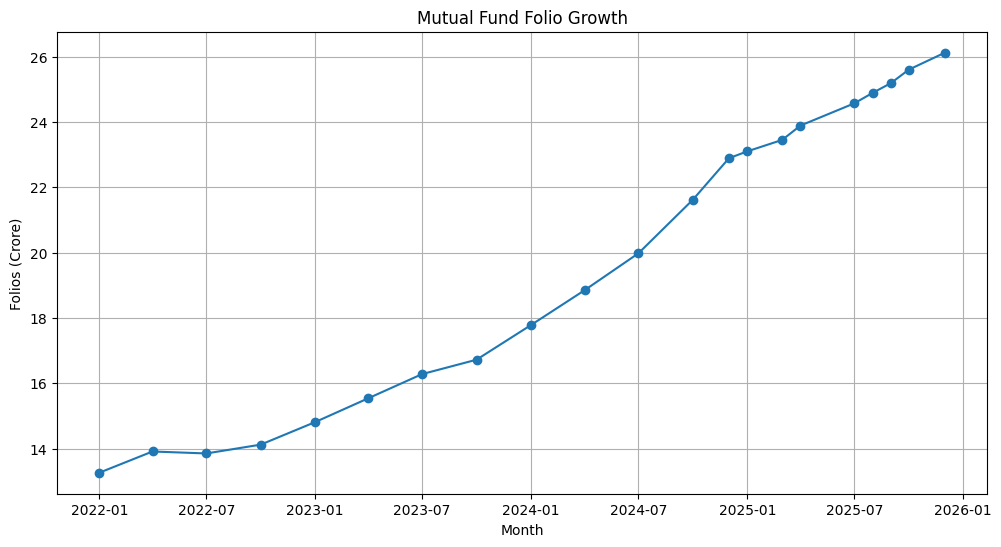

In [14]:
#Folio Growth Trend
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Mutual Fund Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.grid(True)

plt.show()

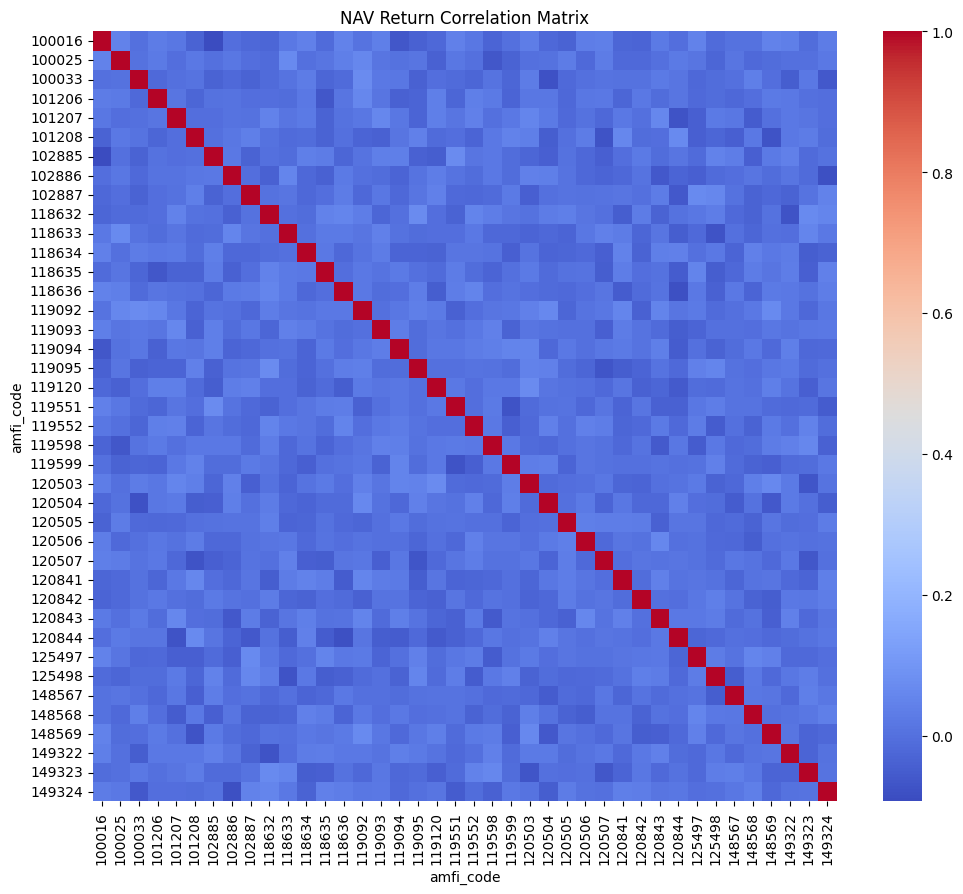

In [15]:
#NAV Correlation Matrix
pivot_nav = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")
plt.show()

In [16]:
#Sector Allocation Donut
sector_data = portfolio.groupby("sector")["weight_pct"].sum()

fig = px.pie(
    values=sector_data.values,
    names=sector_data.index,
    hole=0.5,
    title="Sector Allocation"
)

fig.show()

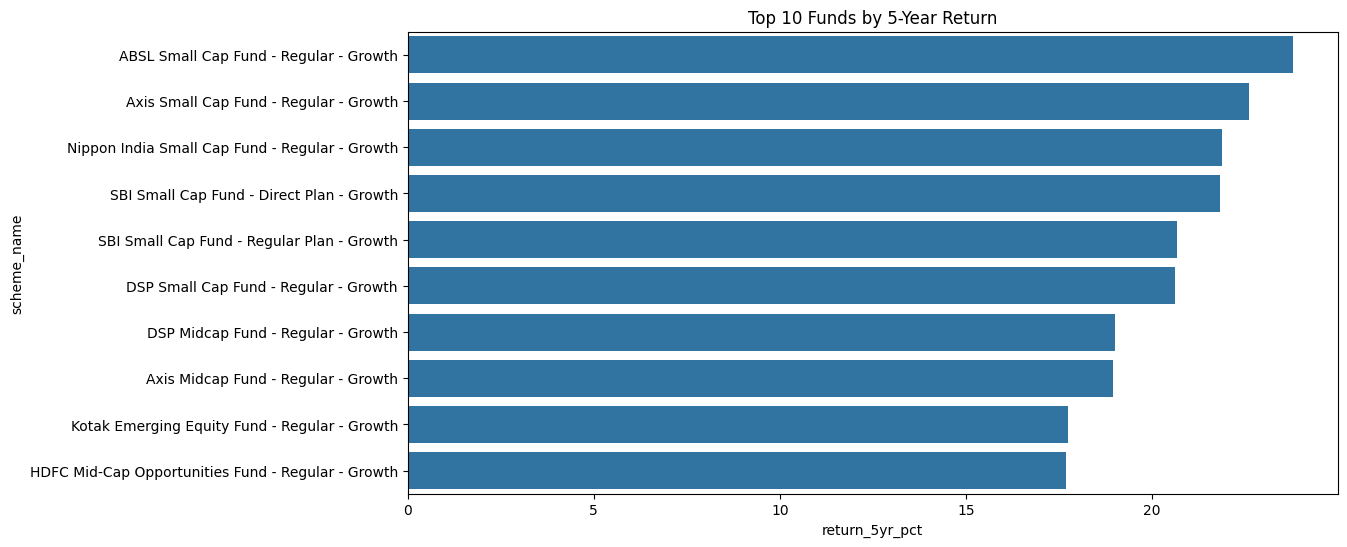

In [17]:
#Top Funds by Return
top_funds = performance.sort_values(
    "return_5yr_pct",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 5-Year Return")
plt.show()

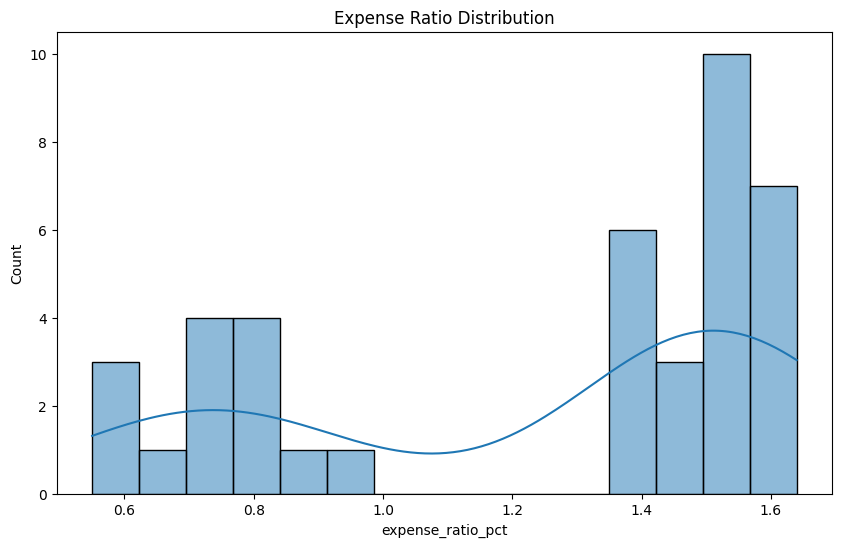

In [18]:
#Expense Ratio Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=15,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.show()

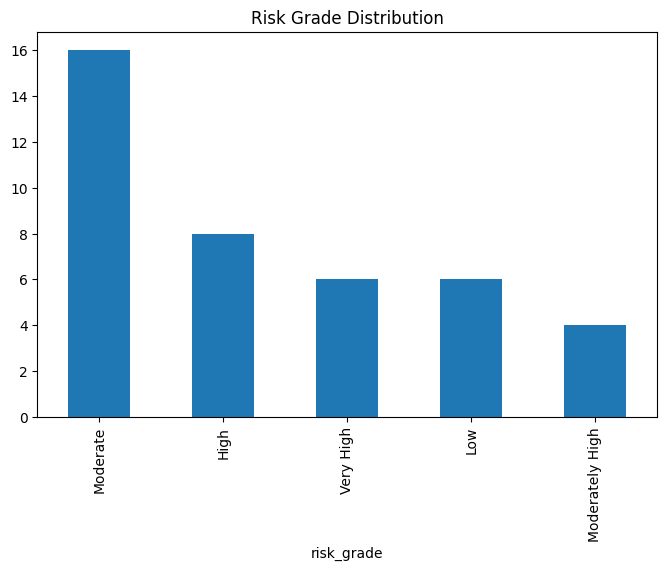

In [19]:
#Risk Grade Distribution
performance["risk_grade"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Risk Grade Distribution")
plt.show()

1. NAV values generally increased during the 2023 bull market.
2. Market correction was visible during early 2024.
3. SBI Mutual Fund maintained the highest AUM across years.
4. SIP inflows showed consistent long-term growth.
5. December 2025 recorded peak SIP inflows.
6. Equity-oriented categories attracted higher inflows.
7. Young and middle-aged investors dominate participation.
8. T30 cities contribute a majority of investments.
9. Folio counts nearly doubled from 2022 to 2025.
10. Most funds exhibit positive long-term returns.